# Image Fundamentals

An image is a tensor of light samples. Every vision model you will ever use starts from this one fact.

## Problem Definition

## Basic Concept

Every production vision system is the same sequence of **reversible transforms.**

### The full preprocessing pipeline at a glance

Every production vision system is the same sequence of reversible transforms. Get one step wrong and the model sees a different input than it was trained on.

```mermaid
flowchart LR
    A["Image file<br/>(JPEG/PNG)"] --> B["Decode<br/>uint8 HWC"]
    B --> C["Convert<br/>colorspace<br/>(RGB/BGR/YCbCr)"]
    C --> D["Resize<br/>shorter side"]
    D --> E["Center crop<br/>model size"]
    E --> F["Divide by 255<br/>float32 [0,1]"]
    F --> G["Subtract mean<br/>Divide by std"]
    G --> H["Transpose<br/>HWC → CHW"]
    H --> I["Batch<br/>CHW → NCHW"]
    I --> J["Model"]

    style A fill:#fef3c7,stroke:#d97706
    style J fill:#ddd6fe,stroke:#7c3aed
    style G fill:#fecaca,stroke:#dc2626
    style H fill:#bfdbfe,stroke:#2563eb
```

The two red and blue boxes are where 80% of silent failures live: missing standardization and wrong layout.

### HWC and CHW

CHW exists because convolution kernels slide across H and W. Keeping the channel axis first means each kernel sees a contiguous 2D plane per channel, which vectorizes cleanly. Disk formats keep HWC because that matches how scanlines come out of a sensor.

### Byte ranges and dType

Three conventions dominate:

| Convention | dtype | Range | Where you see it |
|------------|-------|-------|------------------|
| Raw | `uint8` | [0, 255] | Files on disk, PIL, OpenCV output |
| Normalized | `float32` | [0.0, 1.0] | After `img.astype('float32') / 255` |
| Standardized | `float32` | roughly [-2, +2] | After subtracting mean and dividing by std |

**Convolutional networks were trained on standardized inputs.**

### Color spaces


For most modern CNNs you feed RGB. You meet other spaces when:

- **HSV** — classical CV code, color-based segmentation, white-balancing.
- **YCbCr** — reading JPEG internals, video pipelines, super-resolution models that operate on Y only.
- **Grayscale** — OCR, document models, any case where color is nuisance variable rather than signal.

Grayscale from RGB is **a weighted sum, not an average,** because the human eye is more sensitive to green than to red or blue:

```
Y = 0.299 R + 0.587 G + 0.114 B       (ITU-R BT.601, the classic weights)
```

### Aspect ratio, resizing, and interpolation

Every model has a fixed input size (224x224 for most ImageNet classifiers, 384x384 or 512x512 for modern detectors). Your images rarely match. The three resize choices that matter:

- **Resize shorter side, then center crop** — the standard ImageNet recipe. Preserves aspect ratio, throws away a strip of edge pixels.
- **Resize and pad** — preserves aspect ratio and every pixel, adds black bars. Standard for detection and OCR.
- **Resize directly to target** — stretches the image. Cheap, distorts geometry, fine for many classification tasks.

The interpolation method decides how intermediate pixels are computed when the new grid does not align with the old one:

```
Nearest neighbour     fastest, blocky, only choice for masks/labels
Bilinear              fast, smooth, default for most image resizing
Bicubic               slower, sharper on upscaling
Lanczos               slowest, best quality, used for final display
```

Rule of thumb: bilinear for training, bicubic or lanczos for assets you will look at, nearest for anything containing integer class IDs.

# Build your Own

type: ndarray
dtype: uint8
shape: (128, 192, 3)
min: 0
max: 255
pixel at (0, 0): [128   0   3]


/var/folders/6g/9chj8ddx1033kwmzkbfd95l40000gn/T/ipykernel_52374/3283886160.py:7: RuntimeWarning: invalid value encountered in sqrt
  r = (np.sin(xx * 6) ** 0.5 + 0.5) * 255
/var/folders/6g/9chj8ddx1033kwmzkbfd95l40000gn/T/ipykernel_52374/3283886160.py:11: RuntimeWarning: invalid value encountered in cast
  return np.clip(rgb, 0, 255).astype(np.uint8)


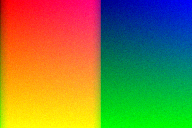

In [14]:
import numpy as np
from PIL import Image

def synthetic_rgb(h=128, w=192, seed=0):
    rng = np.random.default_rng(seed)
    yy, xx  = np.meshgrid(np.linspace(0, 1, h), np.linspace(0, 1, w), indexing="ij")
    r = (np.sin(xx * 6) ** 0.5 + 0.5) * 255
    g = yy * 255
    b = (1 - yy) * xx * 255
    rgb = np.stack([r, g, b], axis=-1) + rng.normal(0, 6, (h, w, 3))
    return np.clip(rgb, 0, 255).astype(np.uint8)

arr = synthetic_rgb()

print(f"type: {type(arr).__name__}")
print(f"dtype: {arr.dtype}")
print(f"shape: {arr.shape}")
print(f"min: {arr.min()}")
print(f"max: {arr.max()}")
print(f"pixel at (0, 0): {arr[0, 0]}")

# Display the image
Image.fromarray(arr)

R shape: (128, 192), mean: 129.8
G shape: (128, 192), mean: 127.0
B shape: (128, 192), mean: 63.5


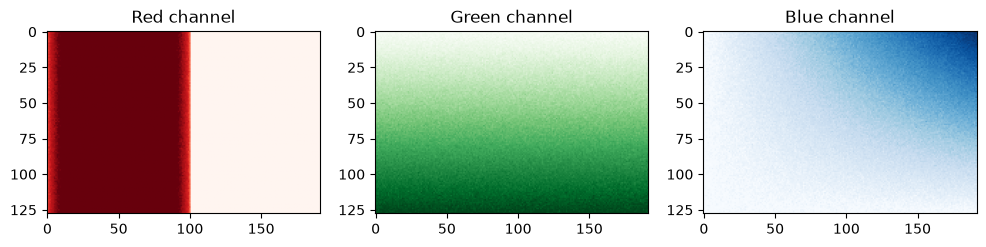

arr_chw shape: (3, 128, 192)


Text(0.5, 1.0, 'Blue channel')

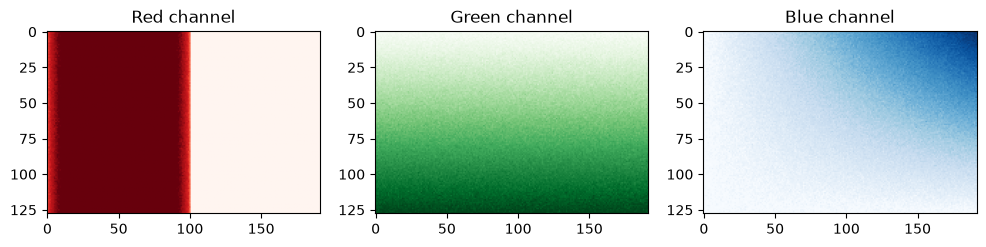

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

R = arr[:, :, 0]
G = arr[:, :, 1]
B = arr[:, :, 2]
print(f"R shape: {R.shape}, mean: {R.mean():.1f}")
print(f"G shape: {G.shape}, mean: {G.mean():.1f}")
print(f"B shape: {B.shape}, mean: {B.mean():.1f}")

# Display the channels
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(R, cmap="Reds")
axs[0].set_title("Red channel")

axs[1].imshow(G, cmap="Greens")
axs[1].set_title("Green channel")

axs[2].imshow(B, cmap="Blues")
axs[2].set_title("Blue channel")

plt.show()

# Convert to arr_chw
arr_chw = arr.transpose(2, 0, 1)
print(f"arr_chw shape: {arr_chw.shape}")

# Display the channels
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(arr_chw[0], cmap="Reds")
axs[0].set_title("Red channel")

axs[1].imshow(arr_chw[1], cmap="Greens")
axs[1].set_title("Green channel")

axs[2].imshow(arr_chw[2], cmap="Blues")
axs[2].set_title("Blue channel")

arr_gray shape: (128, 192)


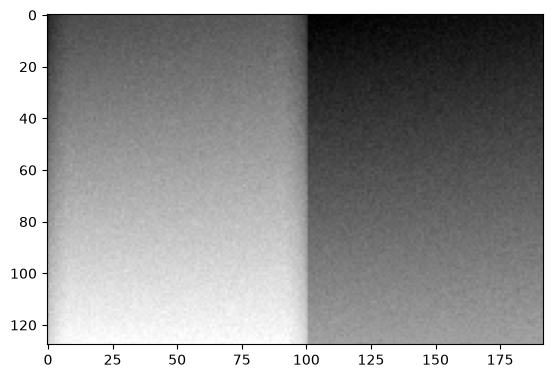

In [16]:
def rgb_to_grayscale(rgb):
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    return (rgb.astype(np.float32) @ weights).astype(np.uint8)

arr_gray = rgb_to_grayscale(arr)
print(f"arr_gray shape: {arr_gray.shape}")

# Display the grayscale image
plt.imshow(arr_gray, cmap="gray")
plt.show()


hsv shape: (128, 192, 3)
hue range: 0.0, 359.7571105957031
saturation range: 0.3388429582118988, 1.0
value range: 0.32156863808631897, 1.0


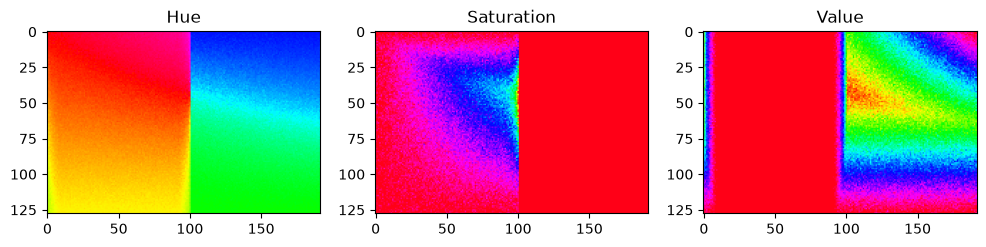

In [19]:
def rgb_to_hsv(rgb):
    """RGB(uint8 HWC) -> HSV，H∈[0,360), S∈[0,1], V∈[0,1]。"""
    # 1) 先归一化到 [0, 1]，后续公式都按浮点比例算
    rgb_f = rgb.astype(np.float32) / 255.0
    r, g, b = rgb_f[:, :, 0], rgb_f[:, :, 1], rgb_f[:, :, 2]

    # 2) 每个像素三个通道的最大/最小，以及色差 chroma = max - min
    #    delta≈0 → 灰/白/黑，没有明确色相
    cmax = np.max(rgb_f, axis=-1)
    cmin = np.min(rgb_f, axis=-1)
    delta = cmax - cmin

    # 3) 计算 Hue（色相）：在色环上的角度，取决于哪个通道最大
    #    R最大 → 偏红黄区；G最大 → 偏绿青区；B最大 → 偏蓝品红区
    h = np.zeros_like(cmax)
    mask = delta > 0                      # 有颜色的像素才算 H，避免除以 0
    rmax = mask & (cmax == r)
    gmax = mask & (cmax == g)
    bmax = mask & (cmax == b)

    # 标准分段公式（结果先落在 [0, 6) 的“扇区坐标”）
    h[rmax] = ((g[rmax] - b[rmax]) / delta[rmax]) % 6   # 扇区 0~1 附近，%6 处理负数
    h[gmax] = ((b[gmax] - r[gmax]) / delta[gmax]) + 2  # 扇区 2~3
    h[bmax] = ((r[bmax] - g[bmax]) / delta[bmax]) + 4  # 扇区 4~5
    h = h * 60                                         # 每扇区 60° → 角度 [0, 360)

    # 4) Saturation（饱和度）：颜色相对亮度有多“纯”
    #    全黑 cmax=0 时无饱和度，置 0；否则 chroma / value
    s = np.where(cmax > 0, delta / cmax, 0)

    # 5) Value（明度）：就是通道最大值，越亮越大
    v = cmax

    # 拼回 (H, W, 3)，通道顺序 HSV
    return np.stack([h, s, v], axis=-1)

hsv = rgb_to_hsv(arr)

print(f"hsv shape: {hsv.shape}")
print(f"hue range: {hsv[:, :, 0].min()}, {hsv[:, :, 0].max()}")
print(f"saturation range: {hsv[:, :, 1].min()}, {hsv[:, :, 1].max()}")
print(f"value range: {hsv[:, :, 2].min()}, {hsv[:, :, 2].max()}")

# Display the HSV channels
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(hsv[:, :, 0], cmap="hsv")
axs[0].set_title("Hue")

axs[1].imshow(hsv[:, :, 1], cmap="hsv")
axs[1].set_title("Saturation")

axs[2].imshow(hsv[:, :, 2], cmap="hsv")
axs[2].set_title("Value")

plt.show()





In [21]:
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_imagenet(rgb_uint8):
    rgb_f = rgb_uint8.astype(np.float32) / 255.0
    rgb_f = (rgb_f - mean) / std
    rgb_f = rgb_f.transpose(2, 0, 1)
    return rgb_f

def depreprocess_imagenet(chw_float32):
    x = chw_float32.transpose(1, 2, 0)
    x = x * std + mean
    x = np.clip(x * 255.0, 0, 255).astype(np.uint8)
    return x



In [ ]:
target = (arr.shape[0] * 3, arr.shape[1] * 3)

print(target)

nearest = np.asarray(Image.fromarray(arr).resize(target[::-1], Image.NEAREST))
bilinear = np.asarray(Image.fromarray(arr).resize(target[::-1], Image.BILINEAR))
bicubic = np.asarray(Image.fromarray(arr).resize(target[::-1], Image.BICUBIC))

def local_roughness(x):
    gy = np.diff(x.astype(float), axis=0)
    gx = np.diff(x.astype(float), axis=1)
    return float(np.abs(gy).mean() + np.abs(gx).mean())


for name, out in [("nearest", nearest), ("bilinear", bilinear), ("bicubic", bicubic)]:
    print(f"{name:>8}  shape={out.shape}  roughness={local_roughness(out):6.2f}")


(384, 576)
 nearest  shape=(384, 576, 3)  roughness=  3.22
bilinear  shape=(384, 576, 3)  roughness=  2.74
 bicubic  shape=(384, 576, 3)  roughness=  3.00


In [ ]:
import torch
from torchvision import transforms
from PIL import Image

img = Image.fromarray(synthetic_rgb(256, 256))

pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img_t = pipeline(img)

x = pipeline(img)
print(f"tensor type:  {type(x).__name__}")
print(f"tensor dtype: {x.dtype}")
print(f"tensor shape: {tuple(x.shape)}      # (C, H, W)")
print(f"per-channel mean: {x.mean(dim=(1, 2)).tolist()}")
print(f"per-channel std:  {x.std(dim=(1, 2)).tolist()}")

batch = x.unsqueeze(0)
print(f"\nbatched shape: {tuple(batch.shape)}   # (N, C, H, W) — ready for a model")
